In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Running Data

In [ ]:

idx_run_VAE = 58
idx_run_VAE2 = 75
idx_run = 58

FileNotFoundError: [Errno 2] No such file or directory: '/Users/markusgambietz/PhD/01_Python_Projects/biomechpriorVAE/qqdotM_runningJoints_VAE_20260309_153325_81.mat'

In [ ]:
joint_indices = {
    "hip_flexion_r": 6,
    "knee_angle_r": 9,
    "ankle_angle_r": 10,
    "hip_flexion_l": 13,
    "knee_angle_l": 16,
    "ankle_angle_l": 17
}
joint_indices_falisse = {
    "hip_flexion": 9,
    "knee_angle": 13,
    "ankle_angle": 15
}


In [ ]:
exp_data = scipy.io.loadmat('/Users/markusgambietz/Downloads/3dpredictsim/OpenSimModel/subject1/IK/IK_average_running_HGC.mat', squeeze_me=True, simplify_cells=True)
fukuchi_mean = np.vstack((exp_data['Qsall']['data'][:,[10,14,16]],exp_data['Qsall']['data'][:,[7,13,15]]))
fukuchi_std = 3
res_Falisse = scipy.io.loadmat('Falisse_273_wMet.mat')['ans']

Mean Absolute Error with prior: 6.02 degrees
Mean Absolute Error with prior 2: 4.87 degrees
Mean Absolute Error without prior: 18.21 degrees
Mean Absolute Error Falisse2019: 17.53 degrees
R with prior: 0.9626
R with prior 2: 0.9673
R without prior: 0.4553
R Falisse2019: 0.5393


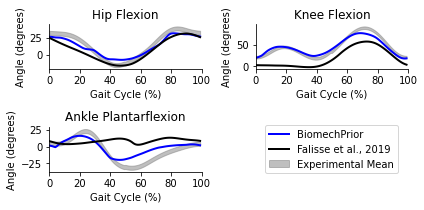

In [ ]:
def start_at_idx(data, idx):
    data_out = data.copy()
    data_out[:-idx] = data[idx:]
    data_out[-idx:] = data[:idx]
    return data_out

fig = plt.figure(figsize=(6, 3))
for i, joint in enumerate(["hip_flexion", "knee_angle", "ankle_angle"]):
    ax = fig.add_subplot(2, 2, i+1)
    plt.title(f"{['Hip Flexion', 'Knee Flexion', 'Ankle Plantarflexion'][i]}")
    dof_arr_VAE = np.hstack((
        res_runningVAE[joint_indices[f"{joint}_r"]],
        res_runningVAE[joint_indices[f"{joint}_l"]],
    ))*180/np.pi
    dof_arr_VAE2 = np.hstack((
        res_runningVAE2[joint_indices[f"{joint}_r"]],
        res_runningVAE2[joint_indices[f"{joint}_l"]],
    ))*180/np.pi
    dof_arr = np.hstack((
        res_running[joint_indices[f"{joint}_r"]],
        res_running[joint_indices[f"{joint}_l"]],
    ))*180/np.pi
    dof_arr_VAE = start_at_idx(dof_arr_VAE, idx_run_VAE)
    dof_arr_VAE2 = start_at_idx(dof_arr_VAE2, idx_run_VAE2)
    dof_arr = start_at_idx(dof_arr, idx_run)

    fac = -1 if joint == "knee_angle" else 1

    plt.plot(fac*dof_arr_VAE.T, color='blue', label='Effort + VAE', linewidth=2)
    #plt.plot(fac*dof_arr_VAE2.T, color='orange', label='Effort + VAE 2', linewidth=2)
    #plt.plot(fac*dof_arr.T, color='black', linestyle='dotted', label='Effort Only', linewidth=2)
    plt.plot(fac*res_Falisse[:,joint_indices_falisse[joint]], color='black', label="Falisse2019", linewidth=2)
    
    plt.fill_between(range(len(fukuchi_mean[:, i])), 
                     fac*fukuchi_mean[:, i] - fukuchi_std, 
                     fac*fukuchi_mean[:, i] + fukuchi_std, 
                     color='gray', alpha=0.5, label='Fukuchi Mean ± Std Dev')
    plt.xlabel('Gait Cycle (%)')
    plt.ylabel('Angle (degrees)')

    plt.xlim(0,100)
    # Remove spines for a cleaner look
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

fig.add_subplot(2, 2, 4)
plt.plot([0], color='blue', label='BiomechPrior', linewidth=2)
#plt.plot([], color='black', label='Effort', linewidth=2, linestyle='dotted')
plt.plot([], color='black', label="Falisse et al., 2019", linewidth=2)
plt.fill_between([ ],
                     [], 
                     [], 
                     color='gray', alpha=0.5, label='Experimental Mean')
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# Remove the axis ticks and numbers
plt.xticks([])
plt.yticks([])
plt.legend(loc='center')
plt.tight_layout()
plt.savefig('running_joint_angles_comparison.pdf', bbox_inches='tight')

# Print the MAE between the simulations and the mean walking data
err_no_prior = 0
err_with_prior = 0
err_with_prior2 = 0
err_Fallise = 0
r_with_prior = 0
r_with_prior2 = 0
r_no_prior = 0
r_Fallise = 0
# calculate r
for i, joint in enumerate(["hip_flexion", "knee_angle", "ankle_angle"]):
    dof_arr_VAE = np.hstack((
        res_runningVAE[joint_indices[f"{joint}_r"]],
        res_runningVAE[joint_indices[f"{joint}_l"]],
    ))*180/np.pi
    dof_arr_VAE2 = np.hstack((
        res_runningVAE2[joint_indices[f"{joint}_r"]],
        res_runningVAE2[joint_indices[f"{joint}_l"]],
    ))*180/np.pi
    dof_arr = np.hstack((
        res_running[joint_indices[f"{joint}_r"]],
        res_running[joint_indices[f"{joint}_l"]],
    ))*180/np.pi

    if idx_run_VAE:
        dof_arr_VAE = start_at_idx(dof_arr_VAE, idx_run_VAE)
    if idx_run_VAE2:
        dof_arr_VAE2 = start_at_idx(dof_arr_VAE2, idx_run_VAE2)
    dof_arr = start_at_idx(dof_arr, idx_run)
    fac = -1 if joint == "knee_angle" else 1
    err_with_prior += np.mean(np.abs(dof_arr_VAE[:100] - fukuchi_mean[:, i]))
    err_with_prior2 += np.mean(np.abs(dof_arr_VAE2[:100] - fukuchi_mean[:, i]))
    err_no_prior += np.mean(np.abs(dof_arr[:100] - fukuchi_mean[:, i]))
    err_Fallise += np.mean(np.abs(res_Falisse[:,joint_indices_falisse[joint]][:100] - fukuchi_mean[:, i]))
    r_with_prior += np.corrcoef(fukuchi_mean[:, i], dof_arr_VAE[:100])[0, 1]
    r_with_prior2 += np.corrcoef(fukuchi_mean[:, i], dof_arr_VAE2[:100])[0, 1]
    r_no_prior += np.corrcoef(fukuchi_mean[:, i], dof_arr[:100])[0, 1]
    r_Fallise += np.corrcoef(fukuchi_mean[:, i], res_Falisse[:,joint_indices_falisse[joint]][:100])[0, 1]
print(f'Mean Absolute Error with prior: {err_with_prior/3:.2f} degrees')
print(f'Mean Absolute Error with prior 2: {err_with_prior2/3:.2f} degrees')
print(f'Mean Absolute Error without prior: {err_no_prior/3:.2f} degrees')
print(f'Mean Absolute Error Falisse2019: {err_Fallise/3:.2f} degrees')
print(f'R with prior: {r_with_prior/3:.4f}')
print(f'R with prior 2: {r_with_prior2/3:.4f}')
print(f'R without prior: {r_no_prior/3:.4f}')
print(f'R Falisse2019: {r_Fallise/3:.4f}')

plt.savefig('running_joint_angles_comparison.pdf', bbox_inches='tight')

In [ ]:
fukuchi_mean.shape

(100, 3)

# Walking Data

In [ ]:
r2_score(winter_mean[:, 1], -1*res_Falisse[:,joint_indices_falisse["knee_angle"]][:100][::2])

NameError: name 'r2_score' is not defined

Mean Absolute Error with prior: 4.49 degrees
Mean Absolute Error Falisse2019: 9.07 degrees
Mean Absolute Error with prior (2): 6.41 degrees
Mean Absolute Error with prior (3): 19.50 degrees
R^2 with prior: 0.9369
R^2 without prior: -0.5855
R^2 Falisse2019: 0.6497
R^2 with prior (2): 0.7060
R^2 with prior (3): -0.4245


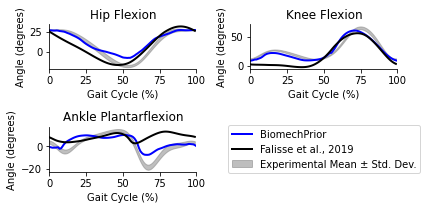

In [ ]:
res_walkingVAE = scipy.io.loadmat('runningJoints1_3.mat')['x']
res_walkingVAE2 = scipy.io.loadmat('results_sim/script3D_1.3/runningJoints_VAE_20251117_173657_81.mat')['runningJoints']
#res_walkingVAE = scipy.io.loadmat('results_sim/script3D_1.3/runningJoints_VAE_20251117_175425_81.mat')['runningJoints']

res_Falisse = scipy.io.loadmat('Falisse_133_wMet.mat')['ans']
res_Falisse2 = scipy.io.loadmat('Falisse_133_noMet.mat')['ans']
idx_walk_VAE = 98
idx_walk_VAE2 = 44
idx_walk_VAE3 = 61
idx_walk_VAE4 = 51
idx_walk = 84
exp_data = scipy.io.loadmat('/Users/markusgambietz/Downloads/3dpredictsim/ExperimentalData/ExperimentalData.mat', squeeze_me=True, simplify_cells=True)
winter_mean = exp_data['ExperimentalData']['Q']['subject1']['Qs']['mean'][:,[6,9,10]]  # Hip, Knee, Ankle
winter_std = exp_data['ExperimentalData']['Q']['subject1']['Qs']['std'][:,[6,9,10]]  # Hip, Knee, Ankle
fig = plt.figure(figsize=(6,3))
for i, joint in enumerate(["hip_flexion", "knee_angle", "ankle_angle"]):
    ax = fig.add_subplot(2, 2, i+1)
    plt.title(f"{['Hip Flexion', 'Knee Flexion', 'Ankle Plantarflexion'][i]}")
    dof_arr_VAE = np.hstack((
        res_walkingVAE[joint_indices[f"{joint}_r"]],
        res_walkingVAE[joint_indices[f"{joint}_l"]],
    ))*180/np.pi
    dof_arr_VAE2 = np.hstack((
        res_walkingVAE2[joint_indices[f"{joint}_r"]],
        res_walkingVAE2[joint_indices[f"{joint}_l"]],
    ))*180/np.pi
    dof_arr_VAE3 = np.hstack((
        res_walkingVAE3[joint_indices[f"{joint}_r"]],
        res_walkingVAE3[joint_indices[f"{joint}_l"]],
    ))*180/np.pi

    #dof_arr = np.hstack((
    #    res_walking[joint_indices[f"{joint}_r"]],
    #    res_walking[joint_indices[f"{joint}_l"]],
    #))*180/np.pi
    if idx_walk_VAE:
        dof_arr_VAE = start_at_idx(dof_arr_VAE, idx_walk_VAE)
    if idx_walk_VAE2:
        dof_arr_VAE2 = start_at_idx(dof_arr_VAE2, idx_walk_VAE2)
    if idx_walk_VAE3:
        dof_arr_VAE3 = start_at_idx(dof_arr_VAE3, idx_walk_VAE3)

    dof_arr = start_at_idx(dof_arr, idx_walk)

    fac = -1 if joint == "knee_angle" else 1
    plt.plot(fac*dof_arr_VAE.T, color='blue', label='Effort + VAE', linewidth=2)
   #plt.plot(fac*dof_arr_VAE2.T, color='orange', label='Effort + VAE (2)', linewidth=2)
   # plt.plot(fac*dof_arr_VAE3.T, color='red', label='Effort + VAE (3)', linewidth=2)

    #plt.plot(fac*dof_arr.T, color='black', label='Effort Only', linewidth=2, linestyle='dotted')
    plt.plot(fac*res_Falisse[:,joint_indices_falisse[joint]], color='black', label="Falisse2019 w/ Met", linewidth=2)
    #plt.plot(fac*res_Falisse2[:,joint_indices_falisse[joint]], color='black', label="Falisse2019", linewidth=1)
    #plt.plot(range(0,100,2),fac*winter[i,:50]*180/np.pi, color='green', label="Winter 2009", linewidth=2)
    plt.fill_between(range(0,100),
                     fac*winter_mean[:, i] - winter_std[:, i], 
                     fac*winter_mean[:, i] + winter_std[:, i], 
                     color='gray', alpha=0.5, label='Winter Mean ± Std Dev')
    plt.xlabel('Gait Cycle (%)')
    plt.ylabel('Angle (degrees)')

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    #plt.gca().spines['left'].set_visible(False)
    #plt.gca().spines['bottom'].set_visible(False)

    plt.xlim(0,100)

fig.add_subplot(2, 2, 4)
plt.plot([0], color='blue', label='BiomechPrior', linewidth=2)
#plt.plot([], color='black', label='Effort', linewidth=2, linestyle='dotted')
plt.plot([], color='black', label="Falisse et al., 2019", linewidth=2)
plt.fill_between([ ],
                     [], 
                     [], 
                     color='gray', alpha=0.5, label='Experimental Mean ± Std. Dev.')
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# Remove the axis ticks and numbers
plt.xticks([])
plt.yticks([])
plt.legend(loc='center')
plt.tight_layout()
plt.savefig('walking_joint_angles_comparison.pdf', bbox_inches='tight')

# Print the MAE between the simulations and the mean walking data
err_no_prior = 0
err_with_prior2 = 0
err_with_prior = 0
err_with_prior3 = 0
err_Fallise = 0
r_with_prior = 0
r_no_prior = 0
r_with_prior2 = 0
r_with_prior3 = 0
r_Fallise = 0
# calculate r
for i, joint in enumerate(["hip_flexion", "knee_angle", "ankle_angle"]):
    dof_arr_VAE = np.hstack((
        res_walkingVAE[joint_indices[f"{joint}_r"]],
        res_walkingVAE[joint_indices[f"{joint}_l"]],
    ))*180/np.pi
    dof_arr_VAE2 = np.hstack((
        res_walkingVAE2[joint_indices[f"{joint}_r"]],
        res_walkingVAE2[joint_indices[f"{joint}_l"]],
    ))*180/np.pi
    dof_arr_VAE3 = np.hstack((
        res_walkingVAE3[joint_indices[f"{joint}_r"]],
        res_walkingVAE3[joint_indices[f"{joint}_l"]],
    ))*180/np.pi
    #dof_arr = np.hstack((
    #    res_walking[joint_indices[f"{joint}_r"]],
    #    res_walking[joint_indices[f"{joint}_l"]],
    #))*180/np.pi
    if idx_walk_VAE:
        dof_arr_VAE = start_at_idx(dof_arr_VAE, idx_walk_VAE)
    if idx_walk_VAE2:
        dof_arr_VAE2 = start_at_idx(dof_arr_VAE2, idx_walk_VAE2)
    if idx_walk_VAE3:
        dof_arr_VAE3 = start_at_idx(dof_arr_VAE3, idx_walk_VAE3)
    dof_arr = start_at_idx(dof_arr, idx_walk)
    fac = -1 if joint == "knee_angle" else 1
    err_with_prior += np.mean(np.abs(dof_arr_VAE[:100] - winter_mean[:, i]))
    err_with_prior2 += np.mean(np.abs(dof_arr_VAE2[:100] - winter_mean[:, i]))
    err_with_prior3 += np.mean(np.abs(dof_arr_VAE3[:100] - winter_mean[:, i]))
    #err_no_prior += np.mean(np.abs(dof_arr[:100] - winter_mean[:, i]))
    err_Fallise += np.mean(np.abs(res_Falisse[:,joint_indices_falisse[joint]][:100] - winter_mean[:, i]))
    r_with_prior += np.corrcoef(winter_mean[:, i], dof_arr_VAE[:100])[0, 1]
    r_with_prior2 += np.corrcoef(winter_mean[:, i], dof_arr_VAE2[:100])[0, 1]
    r_with_prior3 += np.corrcoef(winter_mean[:, i], dof_arr_VAE3[:100])[0, 1]
    r_no_prior += np.corrcoef(winter_mean[:, i], dof_arr[:100])[0, 1]
    r_Fallise += np.corrcoef(winter_mean[:, i], res_Falisse[:,joint_indices_falisse[joint]][:100])[0, 1]
print(f'Mean Absolute Error with prior: {err_with_prior/3:.2f} degrees')
#print(f'Mean Absolute Error without prior: {err_no_prior/3:.2f} degrees')
print(f'Mean Absolute Error Falisse2019: {err_Fallise/3:.2f} degrees')
print(f'Mean Absolute Error with prior (2): {err_with_prior2/3:.2f} degrees')
print(f'Mean Absolute Error with prior (3): {err_with_prior3/3:.2f} degrees')
print(f'R^2 with prior: {r_with_prior/3:.4f}')
print(f'R^2 without prior: {r_no_prior/3:.4f}')
print(f'R^2 Falisse2019: {r_Fallise/3:.4f}')
print(f'R^2 with prior (2): {r_with_prior2/3:.4f}')
print(f'R^2 with prior (3): {r_with_prior3/3:.4f}')

plt.savefig('walking_joint_angles_comparison.pdf', bbox_inches='tight')

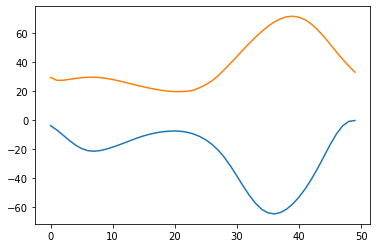

In [ ]:
plt.plot((winter_mean[:, 1]))
plt.plot(-1*res_Falisse[:,joint_indices_falisse["knee_angle"]][:100][::2])


In [ ]:
exp_data = scipy.io.loadmat('/Users/markusgambietz/Downloads/3dpredictsim/OpenSimModel/subject1/IK/IK_average_running_HGC.mat', squeeze_me=True, simplify_cells=True)

In [ ]:
winter = scipy.io.loadmat('Winter_normal_walk_mean.mat')['arr']

In [ ]:
plt.


array([[ 3.37372144e-01,  3.30216294e-01,  3.22013247e-01,
         3.13112068e-01,  3.01941961e-01,  2.86233997e-01,
         2.64940980e-01,  2.38586509e-01,  2.08915911e-01,
         1.78198117e-01,  1.48003921e-01,  1.17635192e-01,
         8.62192650e-02,  5.46288056e-02,  2.47836754e-02,
        -2.26892803e-03, -2.68780705e-02, -5.00909495e-02,
        -7.19075652e-02, -9.25024504e-02, -1.11701072e-01,
        -1.29677963e-01, -1.46433124e-01, -1.61792022e-01,
        -1.74881991e-01, -1.85179434e-01, -1.91113553e-01,
        -1.90415421e-01, -1.79943446e-01, -1.57079633e-01,
        -1.21300383e-01, -7.41764932e-02, -1.83259571e-02,
         4.22369679e-02,  1.03498025e-01,  1.60919357e-01,
         2.11359372e-01,  2.53945406e-01,  2.88502925e-01,
         3.16428193e-01,  3.39466540e-01,  3.58490628e-01,
         3.73151394e-01,  3.81179909e-01,  3.81703507e-01,
         3.75245789e-01,  3.63726616e-01,  3.50636647e-01,
         3.40339204e-01,  3.34754151e-01, -1.85179434e-0

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df_marker_1 = pd.read_csv('/Users/markusgambietz/PhD/01_Python_Projects/mrigait_empkins/data/P03/gait/Trial1.trc', sep='\t', skiprows=3).iloc[1:]

/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_80630/3379760769.py:4: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124) have mixed types. Specify dtype option on import or set low_memory=False.
  df_marker_1 = pd.read_csv('/Users/markusgambietz/PhD/01_Python_Projects/mrigait_empkins/data/P03/gait/Trial1.trc', sep='\t', skiprows=3).iloc[1:]


In [ ]:
df_marker_1.keys()[2::3]

Index(['C7', 'CLAV', 'LANK', 'LASI', 'LBHD', 'LELB', 'LFHD', 'LFIN', 'LFRM',
       'LHEE', 'LKNE', 'LPSI', 'LSHO', 'LTHI', 'LTIB', 'LTOE', 'LUPA', 'LWRA',
       'LWRB', 'RANK', 'RASI', 'RBAK', 'RBHD', 'RELB', 'RFHD', 'RFIN', 'RFRM',
       'RHEE', 'RKNE', 'RPSI', 'RSHO', 'RTHI', 'RTIB', 'RTOE', 'RUPA', 'RWRA',
       'RWRB', 'STRN', 'T10', 'x39', 'x40', 'Unnamed: 125'],
      dtype='object')

/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_80630/717439369.py:2: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df_marker_1 = pd.read_csv('/Users/markusgambietz/PhD/01_Python_Projects/mrigait_empkins/data/P04/gait/Trial1.trc', sep='\t', skiprows=3).iloc[1:]
/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_80630/717439369.py:8: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69

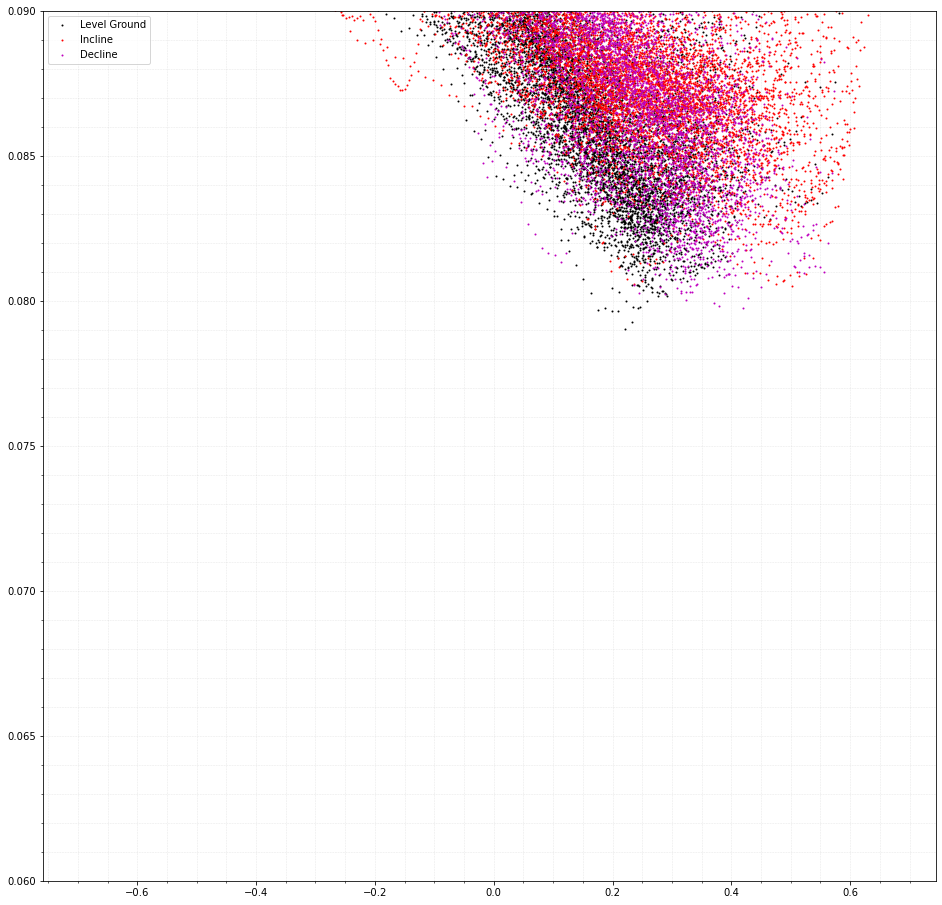

In [ ]:
plt.figure(figsize=(16,16))
df_marker_1 = pd.read_csv('/Users/markusgambietz/PhD/01_Python_Projects/mrigait_empkins/data/P04/gait/Trial1.trc', sep='\t', skiprows=3).iloc[1:]
markers_foot = ['LANK']#,'LHEE','LTOE','RANK','RHEE','RTOE']
index_ = df_marker_1.columns
for m in markers_foot:
    i = list(index_).index(m)
    plt.plot(np.array(df_marker_1.iloc[:,i].astype(float)),np.array(df_marker_1.iloc[:,i+1].astype(float)), 'k.', markersize=2, label='Level Ground')
df_marker_2 = pd.read_csv('/Users/markusgambietz/PhD/01_Python_Projects/mrigait_empkins/data/P04/gait/Trial3.trc', sep='\t', skiprows=3).iloc[1:]
markers_foot = ['LANK']#,'LHEE','LTOE','RANK','RHEE','RTOE']
index_ = df_marker_2.columns
for m in markers_foot:
    i = list(index_).index(m)
    # rotate by 4.57 degrees
    angle = np.deg2rad(-4.57)
    x = np.array(df_marker_2.iloc[:,i].astype(float))
    y = np.array(df_marker_2.iloc[:,i+1].astype(float))
    x_rotated = x * np.cos(angle) - y * np.sin(angle)
    y_rotated = x * np.sin(angle) + y * np.cos(angle)
    plt.plot(x_rotated, y_rotated, 'r.', markersize=2, label='Incline')

df_marker_2 = pd.read_csv('/Users/markusgambietz/PhD/01_Python_Projects/mrigait_empkins/data/P04/gait/Trial5.trc', sep='\t', skiprows=3).iloc[1:]
markers_foot = ['LANK']#,'LHEE','LTOE','RANK','RHEE','RTOE']
index_ = df_marker_2.columns
for m in markers_foot:
    i = list(index_).index(m)
    # rotate by 4.57 degrees
    angle = np.deg2rad(4.57)
    x = np.array(df_marker_2.iloc[:,i].astype(float))
    y = np.array(df_marker_2.iloc[:,i+1].astype(float))
    x_rotated = x * np.cos(angle) - y * np.sin(angle)
    y_rotated = x * np.sin(angle) + y * np.cos(angle)
    plt.plot(x_rotated, y_rotated, 'm.', markersize=2, label='Decline')

plt.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.5)
plt.ylim(0.06,0.09)
plt.minorticks_on()
plt.legend()


/var/folders/zp/1cs5lqq978n6gd_m465gfm840000gn/T/ipykernel_80630/3877458193.py:1: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124) have mixed types. Specify dtype option on import or set low_memory=False.
  df_marker_2 = pd.read_csv('/Users/markusgambietz/PhD/01_Python_Projects/mrigait_empkins/data/P03/gait/Trial3.trc', sep='\t', skiprows=3).iloc[1:]


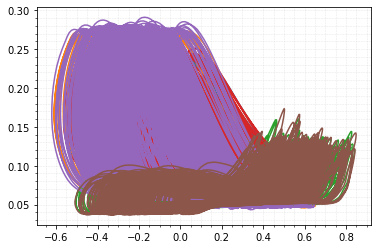

In [ ]:
df_marker_2 = pd.read_csv('/Users/markusgambietz/PhD/01_Python_Projects/mrigait_empkins/data/P03/gait/Trial3.trc', sep='\t', skiprows=3).iloc[1:]
markers_foot = ['LANK','LHEE','LTOE','RANK','RHEE','RTOE']
index_ = df_marker_2.columns
for m in markers_foot:
    i = list(index_).index(m)
    # rotate by 4.57 degrees
    angle = np.deg2rad(-4.57)
    x = np.array(df_marker_2.iloc[:,i].astype(float))
    y = np.array(df_marker_2.iloc[:,i+1].astype(float))
    x_rotated = x * np.cos(angle) - y * np.sin(angle)
    y_rotated = x * np.sin(angle) + y * np.cos(angle)
    plt.plot(x_rotated, y_rotated)

plt.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.5)
plt.minorticks_on()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

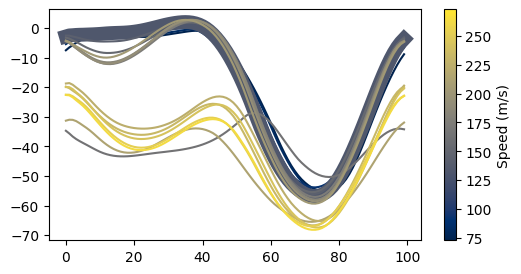

In [ ]:
# get the knee angle from the Falisse results
# cividis colormap, normalized to the speed range
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
res_Falisse = scipy.io.loadmat('Falisse2019_results.mat', squeeze_me=True, simplify_cells=True)

cmap = plt.get_cmap('cividis')
norm = plt.Normalize(vmin=73, vmax=273)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig = plt.figure(figsize=(6, 3))

for speed in range(73,273,10):
    speed_str = str(speed)
    

    a = res_Falisse['Results_all'][f"Speed_{speed_str}"]['W_MetabolicEnergyRate_500']['W_MuscleActivity_2000']['W_JointAcceleration_50000']['W_PassiveTorque_1000']['W_ArmExcitation_1000000']['Power_MetabolicEnergyRate_2']['InitialGuessType_1']['InitialGuessMode_0']['InitialGuessCase_0']['WeaknessHipActuators_0']['WeaknessAnklePlantarflexors_0']['MetabolicEnergyModel_0']['ContactModel_1']['Number_MeshIntervals_50']['MaximumContractionVelocity_0']['CoContraction_0']['Qs_opt']
    if speed == 133:
        plt.plot(a[:, 13],color=cmap(norm(speed)), linewidth=10)
    else:
        plt.plot(a[:, 13],color=cmap(norm(speed)))
plt.colorbar(sm, ax=fig.get_axes(), orientation='vertical', label='Speed (m/s)')


In [ ]:
res_Falisse['Results_all'].keys()

dict_keys(['Speed_133', 'colheaders', 'Speed_123', 'Speed_113', 'Speed_103', 'Speed_93', 'Speed_83', 'Speed_73', 'Speed_143', 'Speed_153', 'Speed_163', 'Speed_173', 'Speed_183', 'Speed_193', 'Speed_203', 'Speed_213', 'Speed_223', 'Speed_233', 'Speed_243', 'Speed_253', 'Speed_263', 'Speed_273'])